In [17]:
import os
import shutil #untuk merekayasa file
import random
import yaml #untuk membaca dataset yaml
from pathlib import Path #untuk membuka file didalam folder

In [18]:
UNIFIED_CLASSES = ["Matang", "Mentah", "Setengah Matang"]

DATASETS = [
    {
        "nama": "Mendeley",
        "images": r"D:/UPH/Skripsi/code/dataset/project-8-at-2026-09-01-23-11-aa5420ca/images",
        "labels": r"D:/UPH/Skripsi/code/dataset/project-8-at-2026-09-01-23-11-aa5420ca/labels",
        "mapping": {0: 0, 1: 1, 2: 2},
    },
    {
        "nama": "Kaggle",
        "images": r"D:/UPH/Skripsi/code/dataset/project-7-at-2026-09-01-23-03-b6a9e0a4/images",
        "labels": r"D:/UPH/Skripsi/code/dataset/project-7-at-2026-09-01-23-03-b6a9e0a4/labels",
        "mapping": {0: 0, 1: 1, 2: 2}
    },
        {
        "nama": "Roboflow",
        "images": r"D:/UPH/Skripsi/code/dataset/Strawberry Ripeness Detection.v6i.yolov8-obb/images",
        "labels": r"D:/UPH/Skripsi/code/dataset/Strawberry Ripeness Detection.v6i.yolov8-obb/labels",
        "mapping": {0: 2, 1: 0, 2: 1}
    },
]

OUTPUT_DIR = "yolo_dataset_gabungan"


In [19]:
CLASS_NAMES = {
    0: "Matang",
    1: "Mentah",
    2: "Setengah Matang"
}

In [20]:
def obb_to_hbb(coords_8):
    xs = [coords_8[i] for i in range(0, 8, 2)]
    ys = [coords_8[i] for i in range(1, 8, 2)]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    xc = (x_min + x_max) / 2
    yc = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min
    return xc, yc, w, h

In [21]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
all_pairs = []

for ds in DATASETS:
    img_dir = Path(ds["images"])
    lbl_dir = Path(ds["labels"])
    img_files = [p for p in img_dir.rglob("*") if p.suffix.lower() in image_extensions]

    count = 0
    for img_path in img_files:
        label_path = lbl_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            candidates = [c for c in lbl_dir.rglob(img_path.stem + ".txt")]
            if candidates:
                label_path = candidates[0]
            else:
                continue

        all_pairs.append((f"{ds['nama']}_{img_path.name}", img_path, label_path, ds["mapping"]))
        count += 1

    print(f"{ds['nama']}: {count} gambar+label")

print("\nTotal gabungan:", len(all_pairs))

Mendeley: 217 gambar+label
Kaggle: 25 gambar+label
Roboflow: 1044 gambar+label

Total gabungan: 1286


In [22]:
random.seed(42)
random.shuffle(all_pairs)

n = len(all_pairs)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

splits = {
    "train": all_pairs[:train_end],
    "val":   all_pairs[train_end:val_end],
    "test":  all_pairs[val_end:],
}

for split_name, pairs in splits.items():
    out_img = Path(OUTPUT_DIR) / "images" / split_name
    out_lbl = Path(OUTPUT_DIR) / "labels" / split_name
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    for new_name, img_path, label_path, mapping in pairs:
        shutil.copy(img_path, out_img / new_name)

        txt_name = Path(new_name).stem + ".txt"
        new_lines = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 9:                      # format OBB
                    new_id = mapping.get(int(parts[0]), int(parts[0]))
                    xc, yc, w, h = obb_to_hbb(list(map(float, parts[1:9])))
                    new_lines.append(f"{new_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
                elif len(parts) >= 5:                    # jaga-jaga kalau ada HBB
                    new_id = mapping.get(int(parts[0]), int(parts[0]))
                    new_lines.append(f"{new_id} " + " ".join(parts[1:5]))

        with open(out_lbl / txt_name, "w") as f:
            f.write("\n".join(new_lines) + ("\n" if new_lines else ""))

print(f"Selesai! Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

Selesai! Train: 900 | Val: 257 | Test: 129


In [23]:
from collections import Counter

dist = Counter()
for new_name, img_path, label_path, mapping in splits["train"]:
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if parts:
                dist[mapping.get(int(parts[0]), int(parts[0]))] += 1

for cls_id, name in enumerate(UNIFIED_CLASSES):
    print(f"Train class '{name}': {dist[cls_id]} samples")

Train class 'Matang': 732 samples
Train class 'Mentah': 1219 samples
Train class 'Setengah Matang': 720 samples


In [24]:
dataset_config = {
    "path": str(Path(OUTPUT_DIR).resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(UNIFIED_CLASSES)}
}

with open("dataset.yaml", "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False)

print(open("dataset.yaml").read())

path: D:\UPH\Skripsi\code\yolo_dataset_gabungan
train: images/train
val: images/val
test: images/test
names:
  0: Matang
  1: Mentah
  2: Setengah Matang



In [25]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib
matplotlib.use('Agg')

from ultralytics import YOLO
import torch

torch.cuda.empty_cache()

model = YOLO("yolov8s.pt")

results = model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=4,
    device=0,
    workers=0,
    plots=False,
    patience=20
)

New https://pypi.org/project/ultralytics/8.4.137 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.133  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

In [28]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from ultralytics import YOLO

model = YOLO("runs/detect/train-13/weights/best.pt")

metrics = model.val(
    data="dataset.yaml",
    split="test",
    plots=True,
    workers=0,
)

print("mAP50 test :", metrics.box.map50)
print("mAP50-95   :", metrics.box.map)

Ultralytics 8.4.133  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 940.7210.0 MB/s, size: 59.2 KB)
val: Scanning D:\UPH\Skripsi\code\yolo_dataset_gabungan\labels\test.cache... 129 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.3it/s 3.9s0.3ss
                   all        129        453      0.736      0.779      0.806      0.554
                Matang         60        111      0.614      0.845      0.762      0.528
                Mentah         56        214       0.76       0.79      0.836      0.565
       Setengah Matang         82        128      0.834      0.703       0.82      0.568
Speed: 0.6ms preprocess, 11.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved t

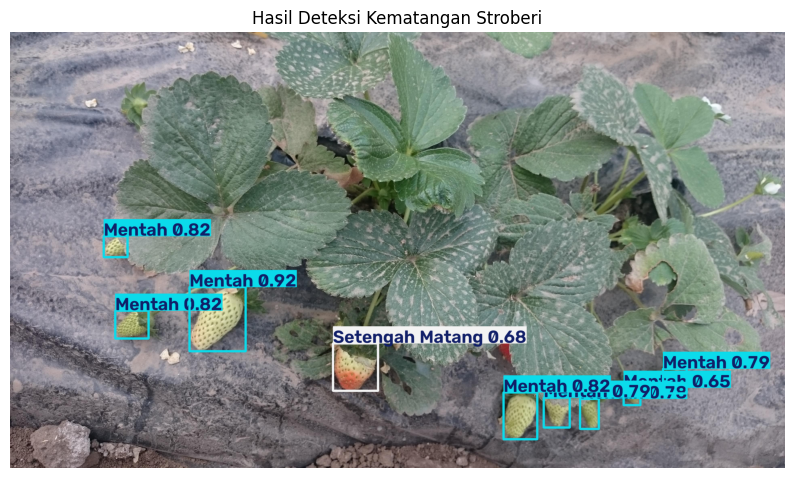

In [29]:
%matplotlib inline
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load model terbaik
BEST_MODEL = r"D:/UPH/Skripsi/code/runs/detect/train-13/weights/best.pt"
model = YOLO(BEST_MODEL)

# 2. Tentukan path gambar yang mau dites (GANTI DENGAN NAMA FILE GAMBAR ANDA)
TEST_IMG = r"D:/UPH/Skripsi/code/yolo_dataset/images/test/ecd72da6-DSC_1272_JPG.rf.b1a44b971fe5a66e68842c6196923a7d.jpg"

# 3. Lakukan prediksi
results = model.predict(source=TEST_IMG, conf=0.45, verbose=False)

# 4. Format gambar agar warna sesuai (BGR ke RGB)
annotated = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

# 5. Tampilkan gambar di notebook
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Hasil Deteksi Kematangan Stroberi")
plt.show()

In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import matplotlib
from ultralytics import YOLO

model = YOLO(r"D:/UPH/Skripsi/code/runs/detect/train-13/weights/best.pt")

metrics = model.val(
    data="dataset.yaml",
    split="val",
    plots=True,
    workers=0,
)

Ultralytics 8.4.133  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 396.2226.9 MB/s, size: 709.8 KB)
val: Scanning D:\UPH\Skripsi\code\yolo_dataset_gabungan\labels\val.cache... 257 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 257/257  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.3it/s 7.3s0.3s
                   all        257        812      0.739      0.857      0.865      0.594
                Matang        125        223      0.701      0.951      0.898      0.623
                Mentah        121        395      0.689      0.784      0.829      0.549
       Setengah Matang        144        194      0.826      0.835      0.868       0.61
Speed: 0.4ms preprocess, 9.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved t